<h2> Wczytanie bibliotek

In [90]:
library(Seurat)
library(CellChat)
library(patchwork)
library(dplyr)
library(ggplot2)
library(NMF)
library(ggalluvial)
options(stringsAsFactors = FALSE)
library(ComplexHeatmap)
library(grid)
library(foreach)

<h2> Wczytanie obiektow

Wczytane tutaj zostały obiekty stworzone w skrypcie cellchat_object_create.ipynb

cellchat_ctrl <- Są to pacienci kontrolni bez blastow

cellchat_leuk <- Są to pacienci chorzy bez blastow

z dodatkiem _blast są to ci sami tylko bez odfiltrowania blastow.

In [ ]:
cellchat_ctrl <- readRDS("cellchat_bez_blastow_ctrl.rds")
cellchat_leuk <- readRDS("cellchat_bez_blastow_leuk.rds")

In [ ]:
cellchat_ctrl_blast <- readRDS("cellchat_ctrl_blast.rds")
cellchat_leuk_blast <- readRDS("cellchat_leuk_blast.rds")

In [77]:
object.list <- list(CTRL = cellchat_ctrl, LEUK = cellchat_leuk)
cellchat_merged <- mergeCellChat(object.list, add.names = names(object.list))

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



In [95]:
object.list1 <- list(CTRL = cellchat_ctrl_blast, LEUK = cellchat_leuk_blast)
cellchat_merged1 <- mergeCellChat(object.list1, add.names = names(object.list1))

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



<h3> Bez Blastów

In [11]:
gg1 <- compareInteractions(cellchat_merged, show.legend = FALSE, group = c(1, 2))
gg2 <- compareInteractions(cellchat_merged, show.legend = FALSE, group = c(1, 2), measure = "weight")
png("plots/comparison/01_interaction_count_vs_strength.png", width = 1200, height = 750, res = 150)
print(gg1 + gg2)
dev.off()

agg_record_641335793 
                   2

<h3> Z blastami

In [96]:
gg1 <- compareInteractions(cellchat_merged1, show.legend = FALSE, group = c(1, 2))
gg2 <- compareInteractions(cellchat_merged1, show.legend = FALSE, group = c(1, 2), measure = "weight")
png("plots/compare_blast/01_interaction_count_vs_strength.png", width = 1200, height = 750, res = 150)
print(gg1 + gg2)
dev.off()

agg_record_837607599 
                   2

<h3> Bez blastów

In [9]:
df_ctrl_clean <- subsetCommunication(cellchat_ctrl) %>% select(source, target, interaction_name, prob) %>% rename(prob_CTRL = prob)
df_leuk_clean <- subsetCommunication(cellchat_leuk) %>% select(source, target, interaction_name, prob) %>% rename(prob_ALL = prob)

In [10]:
df_porownanie <- full_join(df_ctrl_clean, df_leuk_clean, by = c("source", "target", "interaction_name"))
df_porownanie[is.na(df_porownanie)] <- 0

In [12]:
df_porownanie <- df_porownanie %>%
  mutate(
    Roznica_Sily = prob_ALL - prob_CTRL,
    Status = case_when(
      prob_CTRL > 0 & prob_ALL == 0 ~ "UTRACONE w ALL (Wyciszone)",
      prob_CTRL == 0 & prob_ALL > 0 ~ "NOWE w ALL (Aktywowane)",
      Roznica_Sily > 0 ~ "WZMOCNIONE w ALL",
      Roznica_Sily < 0 ~ "OSŁABIONE w ALL",
      TRUE ~ "Bez zmian"
    )
  )

In [14]:
df_summary <- df_porownanie %>%
  filter(Status != "Bez zmian") %>%
  count(Status, name = "Liczba_Interakcji")

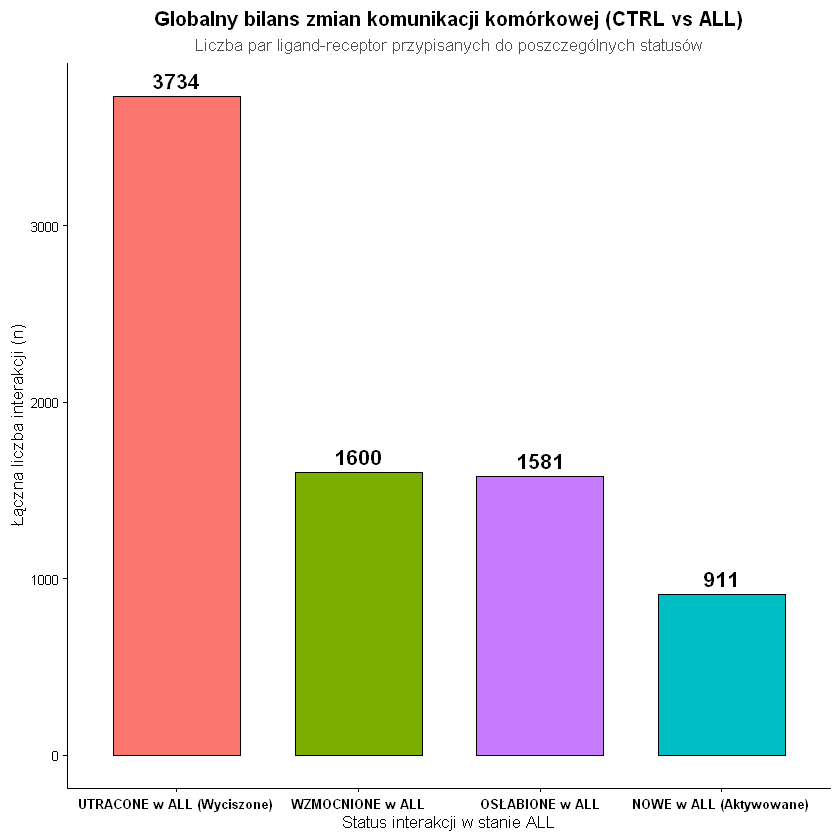

In [22]:
ggplot(df_summary, aes(x = reorder(Status, -Liczba_Interakcji), y = Liczba_Interakcji, fill = Status)) +
  geom_col(color = "black", width = 0.7) +
  geom_text(aes(label = Liczba_Interakcji), vjust = -0.5, fontface = "bold", size = 4.5) +
  scale_fill_manual(values = c(
    "NOWE w ALL (Aktywowane)" = "#00BFC4",
    "WZMOCNIONE w ALL" = "#7CAE00",
    "OSŁABIONE w ALL" = "#C77CFF",
    "UTRACONE w ALL (Wyciszone)" = "#F8766D"
  )) +
  labs(
    title = "Globalny bilans zmian komunikacji komórkowej (CTRL vs ALL)",
    subtitle = "Liczba par ligand-receptor przypisanych do poszczególnych statusów",
    x = "Status interakcji w stanie ALL",
    y = "Łączna liczba interakcji (n)",
    fill = "Status"
  ) +
  theme_classic() +
  theme(
    text = element_text(size = 10),
    plot.title = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5, color = "gray30"),
    axis.text.x = element_text(angle = 0, vjust = 0.8, hjust = 0.5, face = "bold"), # Lekkie pochylenie napisów, żeby się nie nakładały
    legend.position = "none"
  )

<h3> Z blastami

In [97]:
df_ctrl_clean_blast <- subsetCommunication(cellchat_ctrl_blast) %>% select(source, target, interaction_name, prob) %>% rename(prob_CTRL = prob)
df_leuk_clean_blast <- subsetCommunication(cellchat_leuk_blast) %>% select(source, target, interaction_name, prob) %>% rename(prob_ALL = prob)

In [98]:
df_porownanie_blast <- full_join(df_ctrl_clean_blast, df_leuk_clean_blast, by = c("source", "target", "interaction_name"))
df_porownanie_blast[is.na(df_porownanie_blast)] <- 0

In [99]:
df_porownanie_blast <- df_porownanie_blast %>%
  mutate(
    Roznica_Sily = prob_ALL - prob_CTRL,
    Status = case_when(
      prob_CTRL > 0 & prob_ALL == 0 ~ "UTRACONE w ALL (Wyciszone)",
      prob_CTRL == 0 & prob_ALL > 0 ~ "NOWE w ALL (Aktywowane)",
      Roznica_Sily > 0 ~ "WZMOCNIONE w ALL",
      Roznica_Sily < 0 ~ "OSŁABIONE w ALL",
      TRUE ~ "Bez zmian"
    )
  )

In [101]:
df_summary_blast <- df_porownanie_blast %>%
  filter(Status != "Bez zmian") %>%
  count(Status, name = "Liczba_Interakcji")

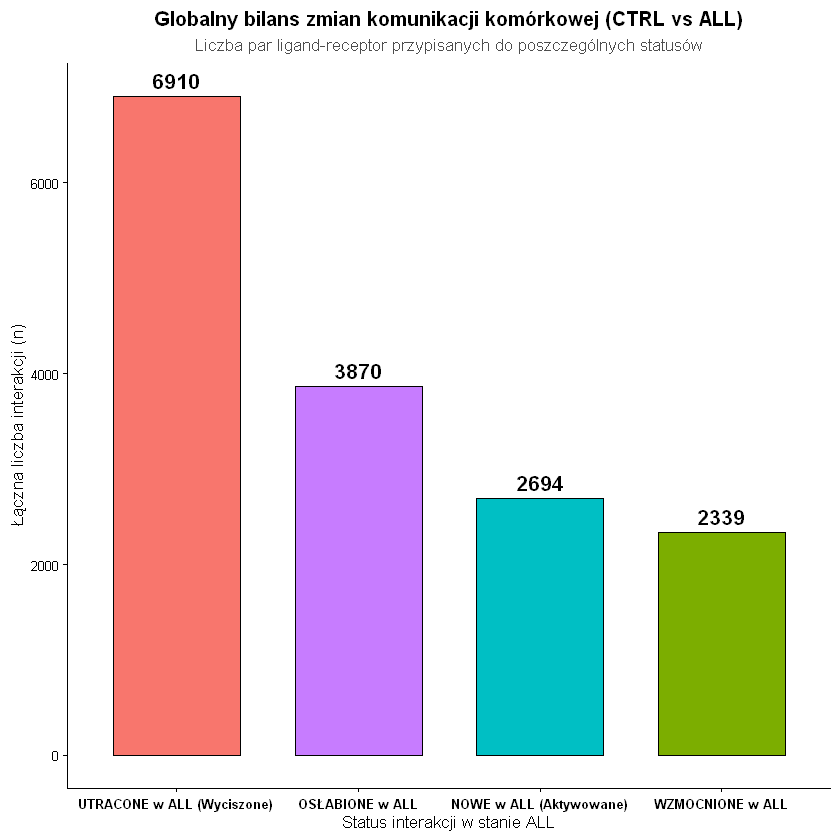

In [102]:
ggplot(df_summary_blast, aes(x = reorder(Status, -Liczba_Interakcji), y = Liczba_Interakcji, fill = Status)) +
  geom_col(color = "black", width = 0.7) +
  geom_text(aes(label = Liczba_Interakcji), vjust = -0.5, fontface = "bold", size = 4.5) +
  scale_fill_manual(values = c(
    "NOWE w ALL (Aktywowane)" = "#00BFC4",
    "WZMOCNIONE w ALL" = "#7CAE00",
    "OSŁABIONE w ALL" = "#C77CFF",
    "UTRACONE w ALL (Wyciszone)" = "#F8766D"
  )) +
  labs(
    title = "Globalny bilans zmian komunikacji komórkowej (CTRL vs ALL)",
    subtitle = "Liczba par ligand-receptor przypisanych do poszczególnych statusów",
    x = "Status interakcji w stanie ALL",
    y = "Łączna liczba interakcji (n)",
    fill = "Status"
  ) +
  theme_classic() +
  theme(
    text = element_text(size = 10),
    plot.title = element_text(face = "bold", hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5, color = "gray30"),
    axis.text.x = element_text(angle = 0, vjust = 0.8, hjust = 0.5, face = "bold"),
    legend.position = "none"
  )

<h3> Różnicowa mapa cieplna

In [ ]:
gg1 <- netVisual_heatmap(cellchat_merged)
gg2 <- netVisual_heatmap(cellchat_merged, measure = "weight")
 
png("plots/comparison/04_differential_heatmaps_bb_1.png", width = 1800, height = 750, res = 150)
print(gg1) 
dev.off()

png("plots/comparison/04_differential_heatmaps_bb_2.png", width = 1800, height = 750, res = 150)
print(gg2)
dev.off()

Do heatmap based on a merged object 


Do heatmap based on a merged object 




agg_record_1809113667 
                    2

<h3> Wykres największych zmian w obrębie komórek bez blastów

In [ ]:
png("plots/comparison/net_signaling_changes.png", width = 1800, height = 750, res = 150)

netAnalysis_signalingChanges_scatter(
  cellchat_merged1, 
  comparison = c(1, 2),
  signaling.target = NULL
)

dev.off()

<h3> Porównanie Information Flow pomiędzy szlakami 

In [ ]:
png("plots/comparison/rankNet_stacked_bb_1.png", width = 1050, height = 1200, res = 150)
rankNet(cellchat_merged, mode = "comparison", stacked = TRUE, do.stat = TRUE)
dev.off()

png("plots/compare_blast/rankNet_stacked_blast_1.png", width = 1050, height = 1200, res = 150)
rankNet(cellchat_merged1, mode = "comparison", stacked = TRUE, do.stat = TRUE)
dev.off()

agg_record_1104177039 
                    2

agg_record_1104177039 
                    2

<h3> Analiza wzorów dla sygnałów wchodzących i wychodzących

In [ ]:
nPatterns_out <- 8 

registerDoSEQ()
cellchat_z_blastami_ctrl <- identifyCommunicationPatterns(
  cellchat_ctrl_blast,
  pattern   = "outgoing",
  k         = nPatterns_out,
  height    = 18
)

pdf("plots/pattern/pattern_river_outgoing_z_blastami_ctrl_dot.pdf", width = 12, height = 8)
netAnalysis_dot(cellchat_z_blastami_ctrl, pattern = "outgoing")
dev.off()

Please make sure you have load `library(ggalluvial)` when running this function



agg_record_1093427620 
                    2

agg_record_1093427620 
                    2

In [ ]:
nPatterns_out <- 5

registerDoSEQ()
cellchat_z_blastami_leuk <- identifyCommunicationPatterns(
  cellchat_leuk_blast,
  pattern   = "outgoing",
  k         = nPatterns_out,
  height    = 18
)

pdf("plots/pattern/pattern_river_outgoing_z_blastami_leuk_dot.pdf", width = 12, height = 8)
netAnalysis_dot(cellchat_z_blastami_leuk, pattern = "outgoing")
dev.off()

Please make sure you have load `library(ggalluvial)` when running this function



agg_record_214141198 
                   2

agg_record_214141198 
                   2

In [ ]:
nPatterns_out <- 8 

registerDoSEQ()
cellchat_z_blastami_ctrl <- identifyCommunicationPatterns(
  cellchat_ctrl_blast,
  pattern   = "incoming",
  k         = nPatterns_out,
  height    = 18
)

pdf("plots/pattern/pattern_river_incoming_z_blastami_ctrl_dot.pdf", width = 12, height = 8)
netAnalysis_dot(cellchat_z_blastami_ctrl, pattern = "incoming")
dev.off()

Please make sure you have load `library(ggalluvial)` when running this function



agg_record_128008306 
                   2

agg_record_128008306 
                   2

In [ ]:
nPatterns_out <- 8

registerDoSEQ()
cellchat_z_blastami_leuk <- identifyCommunicationPatterns(
  cellchat_leuk_blast,
  pattern   = "incoming",
  k         = nPatterns_out,
  height    = 18
)

pdf("plots/pattern/pattern_river_incoming_z_blastami_leuk_dot.pdf", width = 12, height = 8)
netAnalysis_dot(cellchat_z_blastami_leuk, pattern = "incoming")
dev.off()

Please make sure you have load `library(ggalluvial)` when running this function



agg_record_1860018291 
                    2

agg_record_1860018291 
                    2

<h3> Wizualizacja Neureksyny

In [ ]:
png("plots/comparison/NRXN_circle_network_leuk.png", width = 1000, height = 1000, res = 150)

netVisual_individual(
  cellchat_leuk_blast, 
  signaling = "NRXN",
  layout = "circle"
)

dev.off()

[[1]]


agg_record_708641676 
                   2